# Assignment 2: Housing Price Prediction
### Linear Regression on Housing Dataset

**Objective:** Predict `price` using numeric features from the housing dataset.



## 1. Import Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv("Housing.csv")

# Display first 5 rows
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Basic information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# Shape of the dataset (rows, columns)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 545
Columns: 13


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Statistical summary of numeric columns
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
# Check for missing values in each column
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

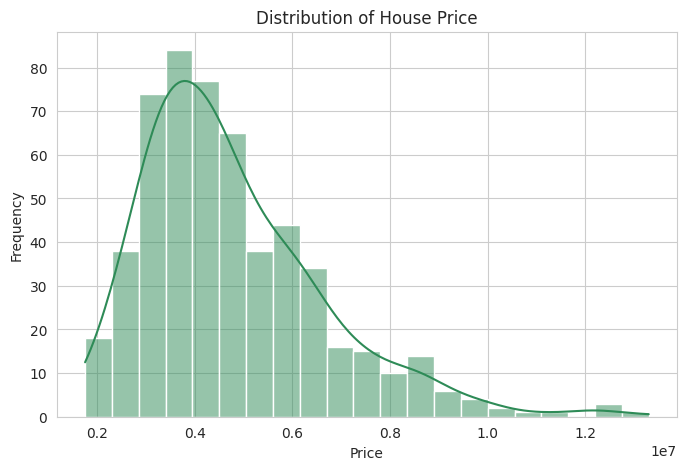

In [7]:
# Distribution of the target variable: price
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='seagreen')
plt.title("Distribution of House Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


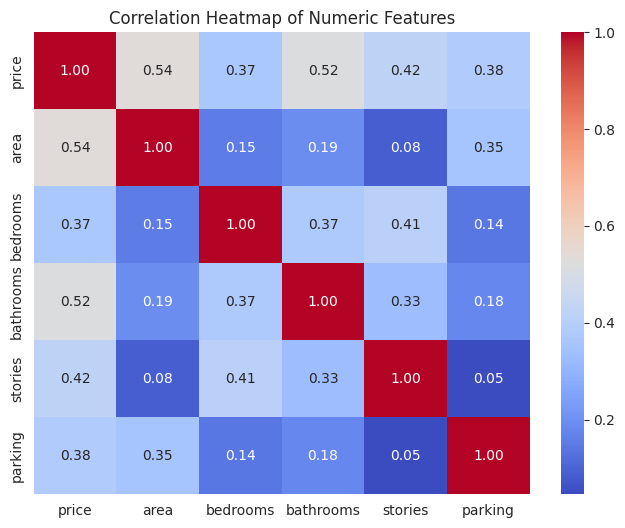

In [8]:
# Correlation heatmap of numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


## 4. Data Cleaning & Feature Selection

The assignment requires using the remaining **numeric columns** as features to predict `price`.
Many columns in this dataset (`mainroad`, `guestroom`, `basement`, `hotwaterheating`,
`airconditioning`, `prefarea`, `furnishingstatus`) are categorical (yes/no or text), so as
instructed, we keep only the numeric columns and drop the categorical ones.


In [9]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Confirm which numeric columns we are working with
print("Numeric columns used:")
print(numeric_df.columns.tolist())


Numeric columns used:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [10]:
# Check again for missing values in the numeric subset
numeric_df.isnull().sum()


price        0
area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
dtype: int64

In [11]:
# Define features (X) and target (y)
X = numeric_df.drop(columns=['price'])
y = numeric_df['price']

print("Feature columns:", X.columns.tolist())
print("Target column: price")


Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Target column: price


## 5. Train-Test Split

In [12]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 436
Testing samples: 109


## 6. Train the Linear Regression Model

In [13]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


In [14]:
# View model coefficients (how much each feature affects price)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Intercept:", model.intercept_)
coeff_df


Intercept: 51999.67680883687


,Feature,Coefficient
2,bathrooms,1.185732e+06
3,stories,4.951008e+05
4,parking,3.376608e+05
1,bedrooms,1.512468e+05
0,area,3.088670e+02


## 7. Make Predictions on Test Data

In [15]:
# Predict prices for the test set
y_pred = model.predict(X_test)

# Compare actual vs predicted values
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': np.round(y_pred, 2)
})
results_df.head(10)


,Actual,Predicted
0,4060000,6178627.50
1,6650000,6370140.86
2,3710000,3283148.16
3,6440000,4226007.95
4,2800000,3409685.55
5,4900000,4262158.35
6,5250000,5493440.53
7,4543000,5559897.74
8,2450000,3373715.42
9,3353000,3020513.19


## 8. Model Evaluation

In [16]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-" * 30)
print(f"MAE  (Mean Absolute Error)     : {mae:.2f}")
print(f"MSE  (Mean Squared Error)      : {mse:.2f}")
print(f"RMSE (Root Mean Squared Error) : {rmse:.2f}")
print(f"R2 Score                       : {r2:.4f}")


Model Evaluation Metrics
------------------------------
MAE  (Mean Absolute Error)     : 1127483.35
MSE  (Mean Squared Error)      : 2292721545725.36
RMSE (Root Mean Squared Error) : 1514173.55
R2 Score                       : 0.5464


In [17]:
# Put metrics in a clean summary table
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Value': [mae, mse, rmse, r2]
})
metrics_df


,Metric,Value
0,MAE,1.127483e+06
1,MSE,2.292722e+12
2,RMSE,1.514174e+06
3,R2 Score,5.464062e-01


## 9. Visualize Actual vs Predicted Results

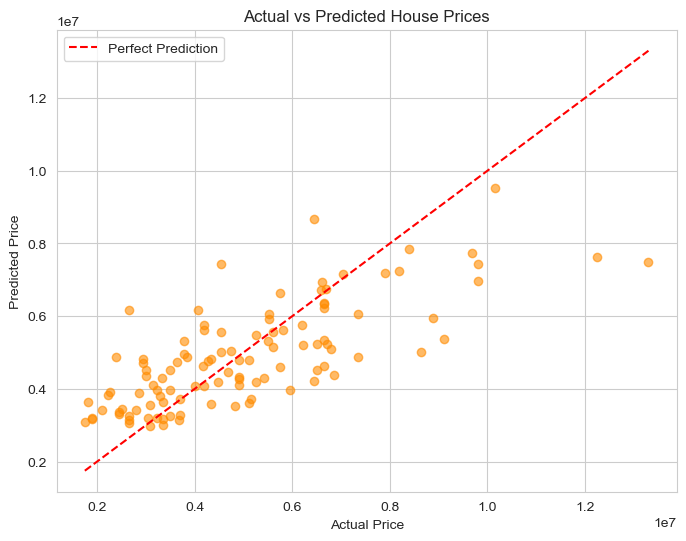

In [18]:
# Scatter plot: Actual vs Predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()


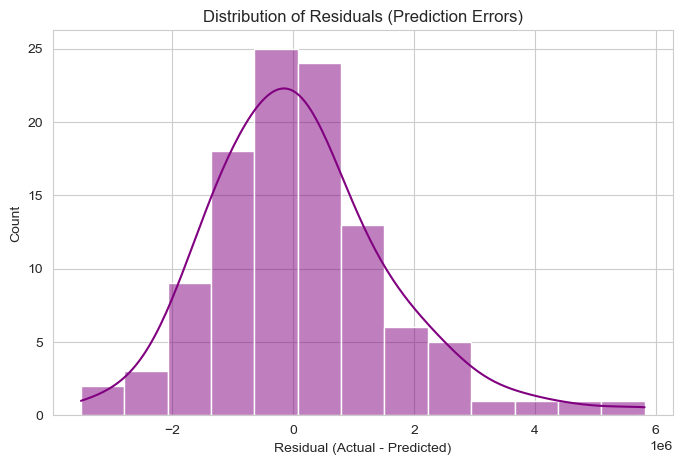

In [19]:
# Residual plot (errors distribution)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribution of Residuals (Prediction Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()
